<a href="https://colab.research.google.com/github/25730018/colab-notebooks/blob/main/%E3%83%87%E3%83%BC%E3%82%BF%E6%8B%A1%E5%BC%B5%E6%AF%94%E8%BC%83%E6%A4%9C%E8%A8%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
フォント設定 完了
データを読み込み中...
読み込み完了。各データのサンプル数:
  hutuu: (5859, 3)
  tiisai: (4284, 3)
  ookii: (5911, 3)
  kousoku: (3600, 3)
  teisoku: (8000, 3)

❶ 振幅拡張の検証

【実測のRMS比率（tiisai/hutuu, ookii/hutuu）】
                  ch1      ch2      ch3       平均
------------------------------------------------
small実測         1.059    1.532    0.496    1.029
large実測         1.242    1.687    1.980    1.636

【設定値との比較】
  実際の拡張範囲  small: [0.7, 1.0],  large: [1.0, 1.3]
  検証に使った固定値: small=0.7（smallの最小値）, large=1.3（largeの最大値）

  small実測平均 1.029 vs 拡張範囲 [0.7, 1.0]
  → 実測比率が拡張範囲内？ ✗ NO（実物の比率が範囲外）

  large実測平均 1.636 vs 拡張範囲 [1.0, 1.3]
  → 実測比率が拡張範囲内？ ✗ NO（実物の比率が範囲外）


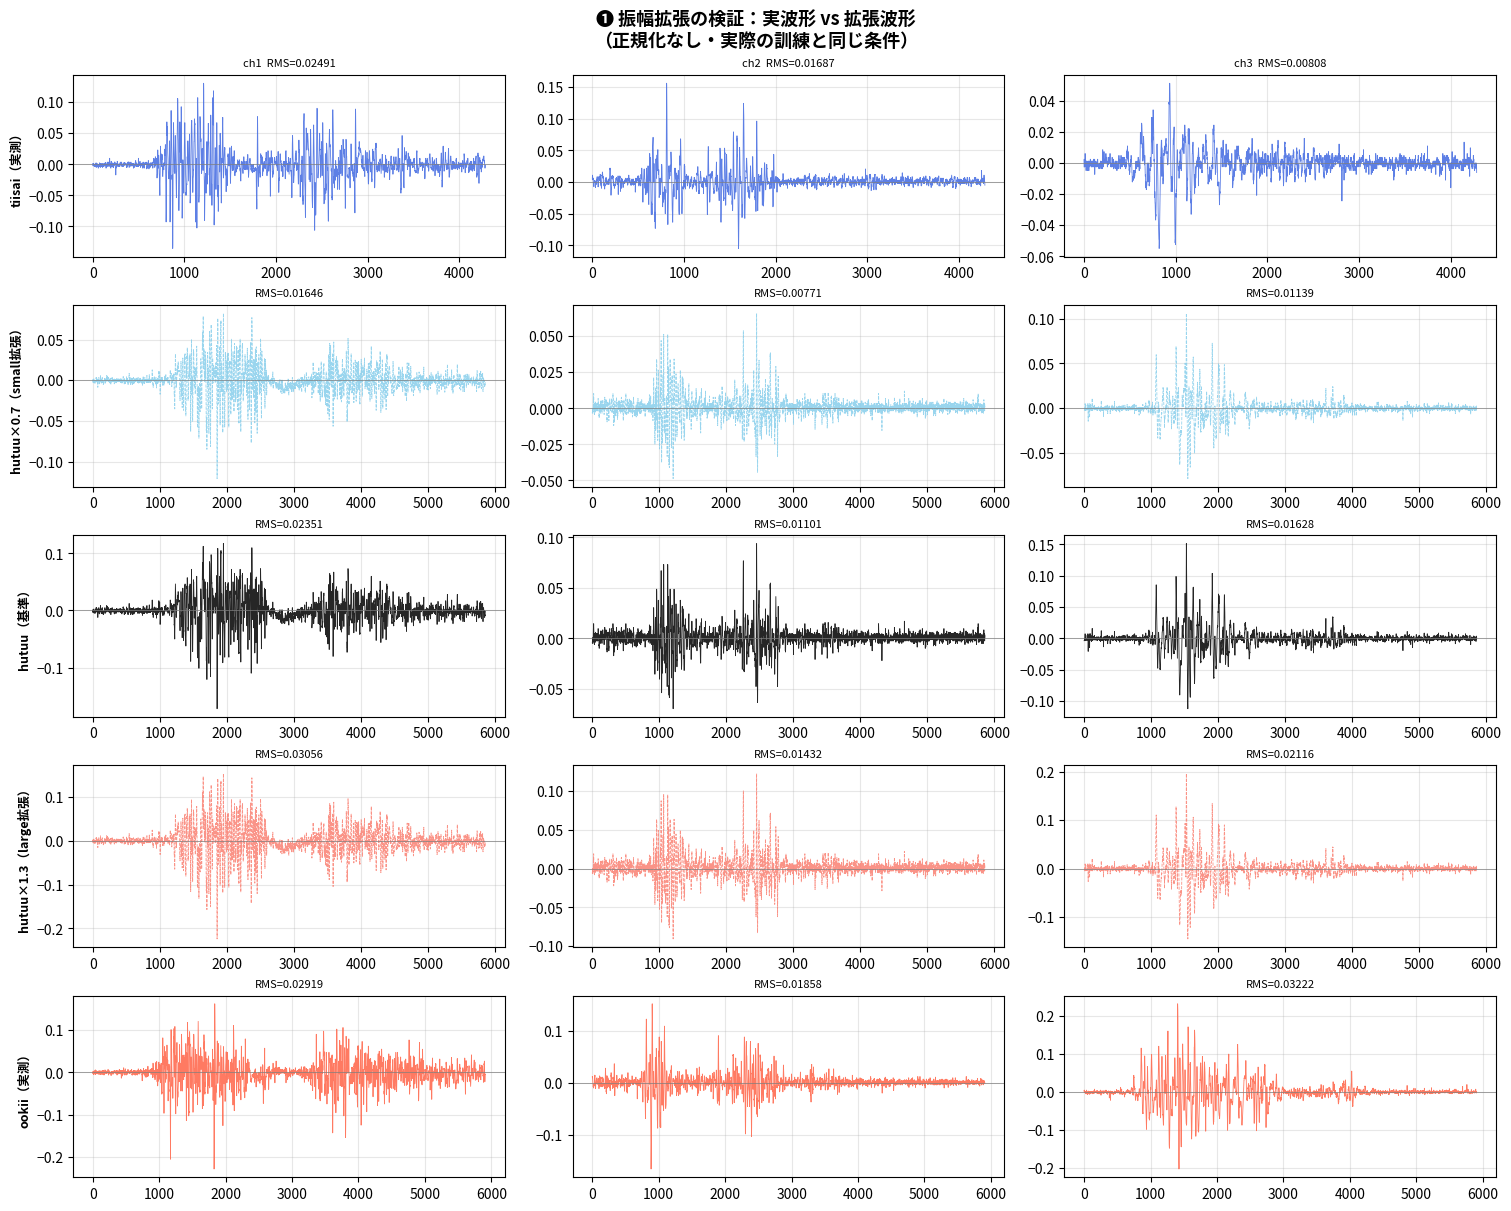

→ amplitude_verification_v2.png を保存しました

❷ 発話速度の検証（DTW）
  実際の拡張範囲  fast: [0.7, 1.0],  slow: [1.0, 1.3]
  検証に使った固定値: fast=0.7（fastの最小値）, slow=1.3（slowの最大値）

時間伸縮データを生成中...
  hutuu元波形:   5859 サンプル
  aug_fast(×0.7): 4101 サンプル
  aug_slow(×1.3): 7616 サンプル
  kousoku実測:   3600 サンプル
  teisoku実測:   8000 サンプル

DTW計算中...

【DTW距離の比較（RMSエンベロープ、チャンネル平均）】
----------------------------------------------------
  hutuu → kousoku（参照）           :   0.0655
  fast拡張 → kousoku（目標）✓         :   0.0484
  fast拡張 → teisoku（クロス）         :   0.1665
  hutuu → teisoku（参照）           :   0.1783
  slow拡張 → teisoku（目標）✓         :   0.1479
  slow拡張 → kousoku（クロス）         :   0.0816

【判定】
  fast拡張は元より kousoku に近づいた？ ✓ YES  (0.0484 vs 元:0.0655)
  fast拡張は teisoku より kousoku に近い？ ✓ YES  (kousoku:0.0484 vs teisoku:0.1665)
  slow拡張は元より teisoku に近づいた？ ✓ YES  (0.1479 vs 元:0.1783)
  slow拡張は kousoku より teisoku に近い？ ✗ NO  (teisoku:0.1479 vs kousoku:0.0816)


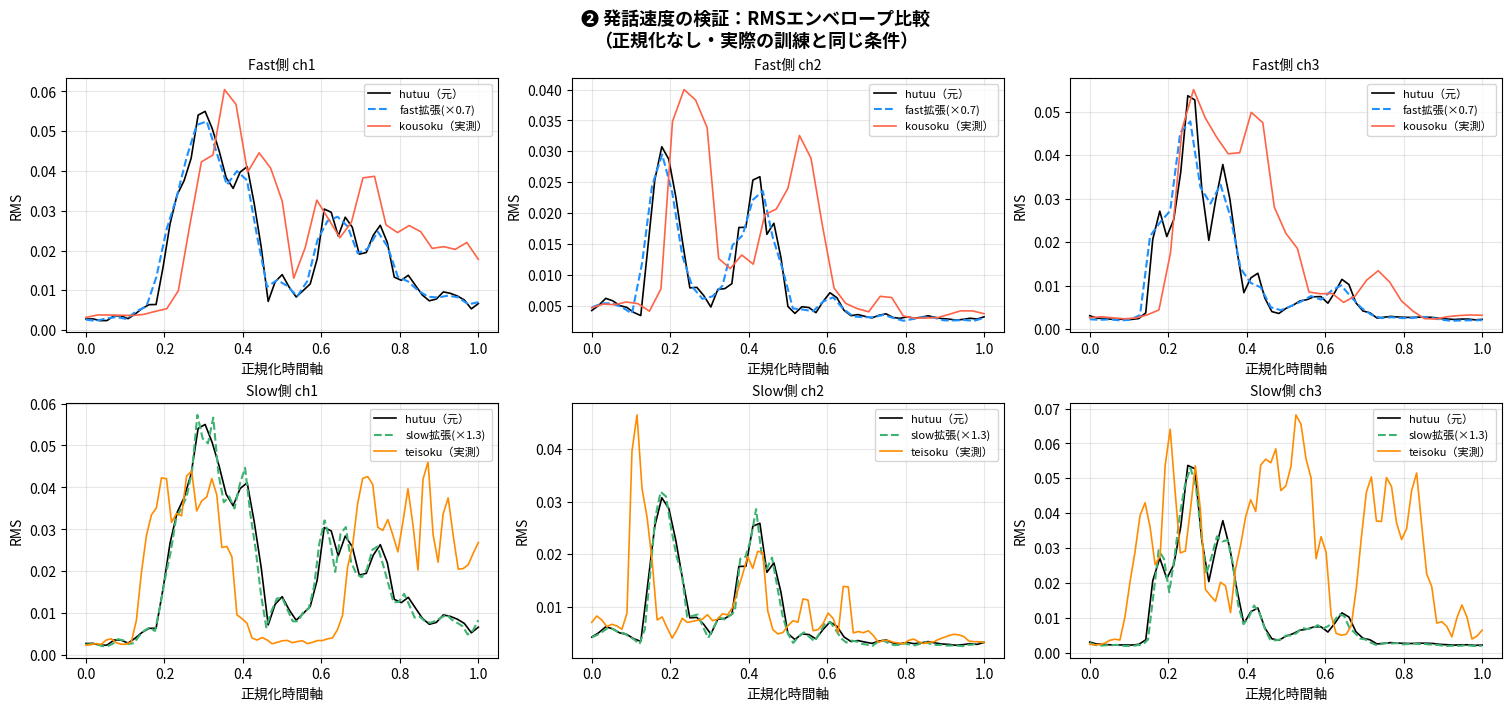

→ dtw_verification_v2.png を保存しました

【総合まとめ】

❶ 振幅拡張
  tiisai/hutuu 実測: 1.029  拡張範囲: [0.7, 1.0]
  ookii/hutuu  実測: 1.636  拡張範囲: [1.0, 1.3]
  small → 範囲外 ✗（拡張範囲を見直し推奨）
  large → 範囲外 ✗（拡張範囲を見直し推奨）

❷ DTW（発話速度）
  fast拡張 → kousokuを模倣できている ✓
  slow拡張 → 模倣が不十分 ✗


In [ ]:
# ============================================================
#  データ拡張の妥当性検証コード（Colabに貼り付けて使用）
#  ❶ 振幅拡張の検証：RMS比率の比較
#  ❷ 発話速度の検証：DTW距離の比較
# ============================================================

# ===== セル1: Googleドライブのマウント =====
from google.colab import drive
drive.mount('/content/drive')

# ===== セル2: ライブラリのインポート =====
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import matplotlib.font_manager as fm


# =====================================================================
# Google Colab で日本語フォントを使えるようにする設定
# =====================================================================
!apt-get -y install fonts-noto-cjk > /dev/null 2>&1

# インストールしたフォントをmatplotlibに登録
fm.fontManager.__init__()
plt.rcParams['font.family'] = 'Noto Sans CJK JP'

print('フォント設定 完了')

# ===== セル3: 設定 =====
PATH  = 'drive/MyDrive/suzuki_Data/suzuki/2025-07-17/emg2025-07-17-15-53-59/'
MIN1  = 0
MAX_  = 8000
CH_LABELS = ['ch1', 'ch2', 'ch3']

# ─────────────────────────────────────────────────────────────
# 【重要】実際の訓練コード(process_and_save)と同じ設定
#   small: ランダム [0.7, 1.0]  → 検証では境界の 0.7 を使用
#   large: ランダム [1.0, 1.3]  → 検証では境界の 1.3 を使用
#   fast : ランダム [0.7, 1.0]  → 検証では境界の 0.7 を使用
#   slow : ランダム [1.0, 1.3]  → 検証では境界の 1.3 を使用
# ─────────────────────────────────────────────────────────────
AMP_SMALL_RANGE  = [0.7, 1.0]  # tiisai 相当
AMP_LARGE_RANGE  = [1.0, 1.3]  # ookii 相当
TIME_FAST_RANGE  = [0.7, 1.0]  # kousoku 相当
TIME_SLOW_RANGE  = [1.0, 1.3]  # teisoku 相当

# 検証用の固定値（各範囲の境界値を使用）
AMP_SMALL_FIXED  = 0.7   # smallの最小値（最も影響が大きい）
AMP_LARGE_FIXED  = 1.3   # largeの最大値（最も影響が大きい）
TIME_FAST_FIXED  = 0.7   # fastの最小値（最も影響が大きい）
TIME_SLOW_FIXED  = 1.3   # slowの最大値（最も影響が大きい）

# ===== セル4: 関数定義 =====

# ---------- データ読み込み ----------
def load_emg(word, path=PATH, min1=MIN1, max_=MAX_):
    """指定ワードのCSVを1ファイル読み込み, shape: (N, 3)"""
    files = glob.glob(str(Path(path) / word / '*.csv'))
    if not files:
        raise FileNotFoundError(f"CSVが見つかりません: {word}")
    df = pd.read_csv(files[0], skiprows=13, header=None)
    return df.iloc[min1:max_, 0:3].values.astype(np.float64)

# ---------- 実際の訓練コードと同じデータ拡張関数 ----------
def raw_amplitude_scaling(data_1ch, scale_range=[0.7, 1.0]):
    """
    【実際の訓練コードと同じ】
    チャンネルごとに独立したランダム値でスケーリング。
    検証用に scale_factor を返り値に追加。
    """
    scale_factor = np.random.uniform(*scale_range)
    return data_1ch * scale_factor, scale_factor

def raw_time_stretch(data_1ch, stretch_range=[0.7, 1.0]):
    """
    【実際の訓練コードと同じ】
    1チャンネル分の時間伸縮。
    """
    stretch_factor = np.random.uniform(*stretch_range)
    old_indices = np.arange(len(data_1ch))
    new_length  = int(len(data_1ch) * stretch_factor)
    new_indices = np.linspace(0, len(data_1ch) - 1, new_length)
    stretched   = np.interp(new_indices, old_indices, data_1ch)
    return stretched, stretch_factor

def apply_amplitude_scaling_multichannel(data, scale_range, fixed_factor=None):
    """
    3チャンネルデータに振幅拡張を適用。
    fixed_factor: Noneなら各chに独立ランダム値、数値なら全ch共通の固定値。
    """
    result = np.zeros_like(data)
    factors = []
    for ch in range(data.shape[1]):
        if fixed_factor is not None:
            f = fixed_factor
            result[:, ch] = data[:, ch] * f
        else:
            result[:, ch], f = raw_amplitude_scaling(data[:, ch], scale_range)
        factors.append(f)
    return result, factors

def apply_time_stretch_multichannel(data, stretch_range, fixed_factor=None):
    """
    3チャンネルデータに時間伸縮を適用。
    fixed_factor: Noneなら各chに独立ランダム値、数値なら全ch共通の固定値。
    注意：チャンネルごとに伸縮後の長さが変わりうるため、
          検証用では固定値を推奨。
    """
    stretched_chs = []
    factors = []
    for ch in range(data.shape[1]):
        if fixed_factor is not None:
            f = fixed_factor
            old_idx  = np.arange(len(data[:, ch]))
            new_len  = int(len(data[:, ch]) * f)
            new_idx  = np.linspace(0, len(data[:, ch]) - 1, new_len)
            stretched_chs.append(np.interp(new_idx, old_idx, data[:, ch]))
        else:
            stretched, f = raw_time_stretch(data[:, ch], stretch_range)
            stretched_chs.append(stretched)
        factors.append(f)
    # 最短チャンネルに合わせてそろえる（実際のprocess_and_saveと同じ処理）
    min_len = min(len(c) for c in stretched_chs)
    result  = np.stack([c[:min_len] for c in stretched_chs], axis=1)
    return result, factors

# ---------- RMS計算 ----------
def compute_rms_envelope(signal_1ch, frame_size=200, hop_size=100):
    """フレームごとのRMSエンベロープ"""
    n_frames = (len(signal_1ch) - frame_size) // hop_size + 1
    return np.array([
        np.sqrt(np.mean(signal_1ch[i*hop_size : i*hop_size + frame_size]**2))
        for i in range(n_frames)
    ])

def compute_rms_per_channel(data):
    """チャンネルごとの全体RMS, shape: (3,)"""
    return np.sqrt(np.mean(data**2, axis=0))

# ---------- DTW ----------
def dtw_distance(x, y):
    """1次元配列のDTW距離"""
    n, m = len(x), len(y)
    D = np.full((n + 1, m + 1), np.inf)
    D[0, 0] = 0.0
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost    = abs(x[i-1] - y[j-1])
            D[i, j] = cost + min(D[i-1, j], D[i, j-1], D[i-1, j-1])
    return D[n, m]

def dtw_multichannel(data_a, data_b, downsample=4):
    """多チャンネルのDTW距離（RMSエンベロープ、チャンネル平均）"""
    min_ch = min(data_a.shape[1], data_b.shape[1])
    distances = []
    for ch in range(min_ch):
        env_a = compute_rms_envelope(data_a[:, ch])[::downsample]
        env_b = compute_rms_envelope(data_b[:, ch])[::downsample]
        distances.append(dtw_distance(env_a, env_b))
    return np.mean(distances)


# ===== セル5: データ読み込み =====
# ─────────────────────────────────────────────────────────────
# 【修正点③】実際の訓練コードはNormalizeRawDataを使っていないので削除
# process_and_save内では生データをそのまま拡張している
# ─────────────────────────────────────────────────────────────
print("データを読み込み中...")
raw = {
    word: load_emg(word)
    for word in ['hutuu', 'tiisai', 'ookii', 'kousoku', 'teisoku']
}
print("読み込み完了。各データのサンプル数:")
for w, d in raw.items():
    print(f"  {w}: {d.shape}")


# ===== セル6: ❶ 振幅拡張の検証 =====
print("\n" + "="*60)
print("❶ 振幅拡張の検証")
print("="*60)

# --- 実測のRMSと比率 ---
rms_hutuu  = compute_rms_per_channel(raw['hutuu'])
rms_tiisai = compute_rms_per_channel(raw['tiisai'])
rms_ookii  = compute_rms_per_channel(raw['ookii'])

ratio_small = rms_tiisai / rms_hutuu
ratio_large = rms_ookii  / rms_hutuu

print("\n【実測のRMS比率（tiisai/hutuu, ookii/hutuu）】")
print(f"{'':12s} {'ch1':>8s} {'ch2':>8s} {'ch3':>8s} {'平均':>8s}")
print("-"*48)
print(f"{'small実測':12s} {ratio_small[0]:8.3f} {ratio_small[1]:8.3f} {ratio_small[2]:8.3f} {ratio_small.mean():8.3f}")
print(f"{'large実測':12s} {ratio_large[0]:8.3f} {ratio_large[1]:8.3f} {ratio_large[2]:8.3f} {ratio_large.mean():8.3f}")

# ─────────────────────────────────────────────────────────────
# 【修正点①②】
# 実際の訓練では small=[0.7,1.0], large=[1.0,1.3] の範囲でランダム。
# 検証では固定値(範囲の境界値)を使用し、チャンネルごとに独立適用。
# ─────────────────────────────────────────────────────────────
aug_small, factors_s = apply_amplitude_scaling_multichannel(raw['hutuu'], AMP_SMALL_RANGE, fixed_factor=AMP_SMALL_FIXED)
aug_large, factors_l = apply_amplitude_scaling_multichannel(raw['hutuu'], AMP_LARGE_RANGE, fixed_factor=AMP_LARGE_FIXED)

print(f"\n【設定値との比較】")
print(f"  実際の拡張範囲  small: {AMP_SMALL_RANGE},  large: {AMP_LARGE_RANGE}")
print(f"  検証に使った固定値: small={AMP_SMALL_FIXED}（smallの最小値）, large={AMP_LARGE_FIXED}（largeの最大値）")
print()
print(f"  small実測平均 {ratio_small.mean():.3f} vs 拡張範囲 [{AMP_SMALL_RANGE[0]}, {AMP_SMALL_RANGE[1]}]")
in_range_s = AMP_SMALL_RANGE[0] <= ratio_small.mean() <= AMP_SMALL_RANGE[1]
print(f"  → 実測比率が拡張範囲内？ {'✓ YES（拡張が実物を十分カバーしている）' if in_range_s else '✗ NO（実物の比率が範囲外）'}")
print()
print(f"  large実測平均 {ratio_large.mean():.3f} vs 拡張範囲 [{AMP_LARGE_RANGE[0]}, {AMP_LARGE_RANGE[1]}]")
in_range_l = AMP_LARGE_RANGE[0] <= ratio_large.mean() <= AMP_LARGE_RANGE[1]
print(f"  → 実測比率が拡張範囲内？ {'✓ YES（拡張が実物を十分カバーしている）' if in_range_l else '✗ NO（実物の比率が範囲外）'}")

# --- 可視化 ---
fig, axes = plt.subplots(5, 3, figsize=(15, 12), constrained_layout=True)
fig.suptitle("❶ 振幅拡張の検証：実波形 vs 拡張波形\n（正規化なし・実際の訓練と同じ条件）",
             fontsize=13, fontweight='bold')

conditions = [
    ('tiisai（実測）',       raw['tiisai'],   'royalblue', '-'),
    (f'hutuu×{AMP_SMALL_FIXED}（small拡張）', aug_small, 'skyblue',   '--'),
    ('hutuu（基準）',        raw['hutuu'],    'black',     '-'),
    (f'hutuu×{AMP_LARGE_FIXED}（large拡張）', aug_large, 'salmon',    '--'),
    ('ookii（実測）',        raw['ookii'],    'tomato',    '-'),
]

for row, (label, data, color, ls) in enumerate(conditions):
    for ch in range(3):
        ax = axes[row, ch]
        ax.plot(data[:, ch], color=color, lw=0.6, ls=ls, alpha=0.85)
        rms_v = np.sqrt(np.mean(data[:, ch]**2))
        if ch == 0:
            ax.set_ylabel(label, fontsize=9, fontweight='bold')
        if row == 0:
            ax.set_title(f"{CH_LABELS[ch]}  RMS={rms_v:.5f}", fontsize=8)
        else:
            ax.set_title(f"RMS={rms_v:.5f}", fontsize=8)
        ax.grid(alpha=0.3)
        ax.axhline(0, color='gray', lw=0.5)

plt.savefig('/content/drive/MyDrive/amplitude_verification_v2.png', dpi=120, bbox_inches='tight')
plt.show()
print("→ amplitude_verification_v2.png を保存しました")


# ===== セル7: ❷ 発話速度（DTW）の検証 =====
print("\n" + "="*60)
print("❷ 発話速度の検証（DTW）")
print("="*60)
print(f"  実際の拡張範囲  fast: {TIME_FAST_RANGE},  slow: {TIME_SLOW_RANGE}")
print(f"  検証に使った固定値: fast={TIME_FAST_FIXED}（fastの最小値）, slow={TIME_SLOW_FIXED}（slowの最大値）\n")

# ─────────────────────────────────────────────────────────────
# 【修正点①②】
# 実際: fast=[0.7,1.0], slow=[1.0,1.3]（分割済み範囲）
# チャンネルごとに独立ランダム → 検証用に固定値使用
# ─────────────────────────────────────────────────────────────
print("時間伸縮データを生成中...")
aug_fast, factors_f = apply_time_stretch_multichannel(raw['hutuu'], TIME_FAST_RANGE, fixed_factor=TIME_FAST_FIXED)
aug_slow, factors_w = apply_time_stretch_multichannel(raw['hutuu'], TIME_SLOW_RANGE, fixed_factor=TIME_SLOW_FIXED)

print(f"  hutuu元波形:   {raw['hutuu'].shape[0]} サンプル")
print(f"  aug_fast(×{TIME_FAST_FIXED}): {aug_fast.shape[0]} サンプル")
print(f"  aug_slow(×{TIME_SLOW_FIXED}): {aug_slow.shape[0]} サンプル")
print(f"  kousoku実測:   {raw['kousoku'].shape[0]} サンプル")
print(f"  teisoku実測:   {raw['teisoku'].shape[0]} サンプル")

print("\nDTW計算中...")
dtw_results = {
    'hutuu → kousoku（参照）':      dtw_multichannel(raw['hutuu'],  raw['kousoku']),
    'fast拡張 → kousoku（目標）✓': dtw_multichannel(aug_fast,      raw['kousoku']),
    'fast拡張 → teisoku（クロス）': dtw_multichannel(aug_fast,      raw['teisoku']),
    'hutuu → teisoku（参照）':      dtw_multichannel(raw['hutuu'],  raw['teisoku']),
    'slow拡張 → teisoku（目標）✓': dtw_multichannel(aug_slow,      raw['teisoku']),
    'slow拡張 → kousoku（クロス）': dtw_multichannel(aug_slow,      raw['kousoku']),
}

print("\n【DTW距離の比較（RMSエンベロープ、チャンネル平均）】")
print("-"*52)
for label, dist in dtw_results.items():
    print(f"  {label:30s}: {dist:8.4f}")

d_fast_target = dtw_results['fast拡張 → kousoku（目標）✓']
d_fast_ref    = dtw_results['hutuu → kousoku（参照）']
d_fast_cross  = dtw_results['fast拡張 → teisoku（クロス）']
d_slow_target = dtw_results['slow拡張 → teisoku（目標）✓']
d_slow_ref    = dtw_results['hutuu → teisoku（参照）']
d_slow_cross  = dtw_results['slow拡張 → kousoku（クロス）']

print("\n【判定】")
print(f"  fast拡張は元より kousoku に近づいた？ "
      f"{'✓ YES' if d_fast_target < d_fast_ref else '✗ NO'}"
      f"  ({d_fast_target:.4f} vs 元:{d_fast_ref:.4f})")
print(f"  fast拡張は teisoku より kousoku に近い？ "
      f"{'✓ YES' if d_fast_target < d_fast_cross else '✗ NO'}"
      f"  (kousoku:{d_fast_target:.4f} vs teisoku:{d_fast_cross:.4f})")
print(f"  slow拡張は元より teisoku に近づいた？ "
      f"{'✓ YES' if d_slow_target < d_slow_ref else '✗ NO'}"
      f"  ({d_slow_target:.4f} vs 元:{d_slow_ref:.4f})")
print(f"  slow拡張は kousoku より teisoku に近い？ "
      f"{'✓ YES' if d_slow_target < d_slow_cross else '✗ NO'}"
      f"  (teisoku:{d_slow_target:.4f} vs kousoku:{d_slow_cross:.4f})")

# --- 可視化 ---
fig, axes = plt.subplots(2, 3, figsize=(15, 7), constrained_layout=True)
fig.suptitle("❷ 発話速度の検証：RMSエンベロープ比較\n（正規化なし・実際の訓練と同じ条件）",
             fontsize=13, fontweight='bold')

for ch in range(3):
    # Fast側
    ax = axes[0, ch]
    env_hutuu   = compute_rms_envelope(raw['hutuu'][:, ch])
    env_fast    = compute_rms_envelope(aug_fast[:, ch])
    env_kousoku = compute_rms_envelope(raw['kousoku'][:, ch])

    ax.plot(np.linspace(0, 1, len(env_hutuu)),   env_hutuu,   color='black',      lw=1.2, label='hutuu（元）')
    ax.plot(np.linspace(0, 1, len(env_fast)),     env_fast,    color='dodgerblue', lw=1.5, label=f'fast拡張(×{TIME_FAST_FIXED})', ls='--')
    ax.plot(np.linspace(0, 1, len(env_kousoku)),  env_kousoku, color='tomato',     lw=1.2, label='kousoku（実測）')
    ax.set_title(f"Fast側 {CH_LABELS[ch]}", fontsize=10)
    ax.set_xlabel("正規化時間軸")
    ax.set_ylabel("RMS")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # Slow側
    ax = axes[1, ch]
    env_slow    = compute_rms_envelope(aug_slow[:, ch])
    env_teisoku = compute_rms_envelope(raw['teisoku'][:, ch])

    ax.plot(np.linspace(0, 1, len(env_hutuu)),   env_hutuu,   color='black',         lw=1.2, label='hutuu（元）')
    ax.plot(np.linspace(0, 1, len(env_slow)),     env_slow,    color='mediumseagreen',lw=1.5, label=f'slow拡張(×{TIME_SLOW_FIXED})', ls='--')
    ax.plot(np.linspace(0, 1, len(env_teisoku)),  env_teisoku, color='darkorange',    lw=1.2, label='teisoku（実測）')
    ax.set_title(f"Slow側 {CH_LABELS[ch]}", fontsize=10)
    ax.set_xlabel("正規化時間軸")
    ax.set_ylabel("RMS")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.savefig('/content/drive/MyDrive/dtw_verification_v2.png', dpi=120, bbox_inches='tight')
plt.show()
print("→ dtw_verification_v2.png を保存しました")

# ===== セル8: 総合まとめ =====
print("\n" + "="*60)
print("【総合まとめ】")
print("="*60)
print(f"\n❶ 振幅拡張")
print(f"  tiisai/hutuu 実測: {ratio_small.mean():.3f}  拡張範囲: {AMP_SMALL_RANGE}")
print(f"  ookii/hutuu  実測: {ratio_large.mean():.3f}  拡張範囲: {AMP_LARGE_RANGE}")
print(f"  small → {'範囲内 ✓' if in_range_s else '範囲外 ✗（拡張範囲を見直し推奨）'}")
print(f"  large → {'範囲内 ✓' if in_range_l else '範囲外 ✗（拡張範囲を見直し推奨）'}")
print(f"\n❷ DTW（発話速度）")
print(f"  fast拡張 → {'kousokuを模倣できている ✓' if d_fast_target < d_fast_ref and d_fast_target < d_fast_cross else '模倣が不十分 ✗'}")
print(f"  slow拡張 → {'teisokuを模倣できている ✓' if d_slow_target < d_slow_ref and d_slow_target < d_slow_cross else '模倣が不十分 ✗'}")